# AirShift — Final Test Evaluation

This notebook evaluates the final XGBoost model on the completely unseen test period.

The final model was trained using the combined training and validation periods, while the test period was kept separate throughout model development and hyperparameter tuning.

The evaluation focuses on the model's ability to detect future air quality deterioration events on unseen data.


## 1. Load the Dataset

In [1]:
from pathlib import Path
import pandas as pd
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/airshift_labeled.csv")
MODEL_PATH = Path("../models/xgboost_final.joblib")

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])

final_xgb = joblib.load(MODEL_PATH)

print("Dataset shape:", df.shape)
print("Final model loaded successfully.")

Dataset shape: (418381, 100)
Final model loaded successfully.


In [3]:
TEST_START = "2016-01-01 00:00:00"

test_mask = df["datetime"] >= TEST_START

test_df = df.loc[test_mask].copy()

print("Test dataset shape:", test_df.shape)
print("Test date range:", test_df["datetime"].min(), "to", test_df["datetime"].max())

Test dataset shape: (121900, 100)
Test date range: 2016-01-01 00:00:00 to 2017-02-28 17:00:00


## 2. Define Test Features and Target

The test features and target are separated for the final evaluation.

The identifier and datetime columns are excluded from the model features, while the `Deterioration` column is used as the target variable.


In [4]:
TARGET = "Deterioration"
EXCLUDED_COLUMNS = ["Deterioration", "No", "datetime"]

X_test = test_df.drop(columns=EXCLUDED_COLUMNS)
y_test = test_df[TARGET]

print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("Number of features:", X_test.shape[1])

Test features shape: (121900, 97)
Test target shape: (121900,)
Number of features: 97


### Findings

The final XGBoost model was evaluated on the completely unseen 2016–2017 test period.

The model achieved performance comparable to the validation results, with no major degradation on the unseen test data. This indicates that the selected model configuration maintained consistent performance when evaluated on a later time period.

The final test results provide the main performance reference for the AirShift model before moving to model interpretation and deployment.


## 3. Final Test Predictions

The final XGBoost model is used to generate predictions on the completely unseen test period.

No model fitting, hyperparameter tuning, or threshold optimization is performed on the test data.


In [5]:
# Generate test predictions
y_test_pred = final_xgb.predict(X_test)
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

print("Test predictions generated successfully.")

Test predictions generated successfully.


## 4. Test Set Evaluation

The final XGBoost model is evaluated on the held-out test set covering observations from January 2016 to February 2017.

The test set was not used during model development or hyperparameter tuning, providing an unbiased evaluation of the final model's performance on unseen data.

The following metrics are calculated:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Proportion of predicted deterioration events that were actual deterioration events.
- **Recall:** Proportion of actual deterioration events correctly detected by the model.
- **F1 Score:** Harmonic mean of precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between deterioration and non-deterioration cases across classification thresholds.
- **PR-AUC:** Measures performance across precision and recall and is particularly useful for evaluating the model's ability to identify deterioration events.

In [6]:
test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob),
    "PR-AUC": average_precision_score(y_test, y_test_prob)
}

test_results = pd.DataFrame(
    [test_metrics],
    index=["Final XGBoost"]
)

test_results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Final XGBoost,0.7368,0.7244,0.7315,0.7279,0.8215,0.8186


## 5. Confusion Matrix

The confusion matrix provides a detailed view of the final model's classification performance on the unseen test set.

It shows the number of correctly and incorrectly classified observations for both deterioration and non-deterioration events, helping assess the model's ability to detect deterioration events and identify missed warnings.

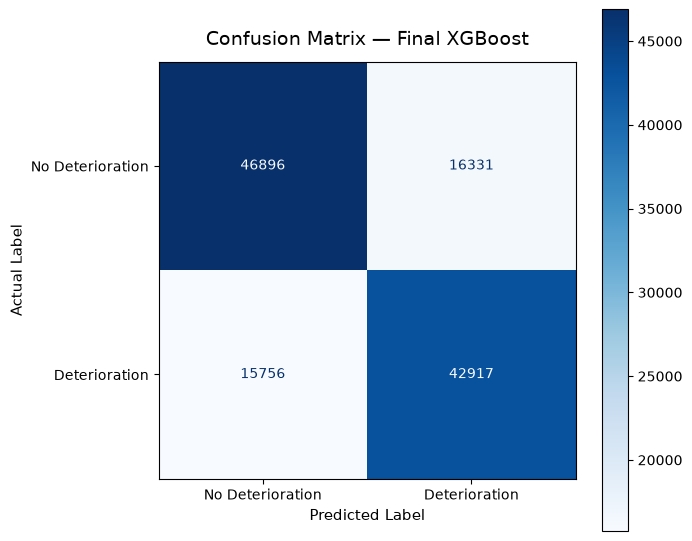

Figure saved to: ..\reports\figures\08_final_test_evaluation\05_confusion_matrix.png


In [7]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create output directory
FIGURES_DIR = Path("../reports/figures/08_final_test_evaluation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Deterioration", "Deterioration"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

ax.set_title(
    "Confusion Matrix — Final XGBoost",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label", fontsize=11)

plt.tight_layout()

# Save figure
FIGURE_PATH = FIGURES_DIR / "05_confusion_matrix.png"
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {FIGURE_PATH}")

### Confusion Matrix Interpretation

The confusion matrix summarizes four types of classification outcomes:

* **True Negative (TN):** A non-deterioration observation correctly classified as non-deterioration.
* **False Positive (FP):** A non-deterioration observation incorrectly classified as deterioration.
* **False Negative (FN):** A deterioration observation incorrectly classified as non-deterioration.
* **True Positive (TP):** A deterioration observation correctly classified as deterioration.

For an early warning system, false negatives are particularly important because they represent deterioration events that the model failed to detect.


In [8]:
# Extract confusion matrix components

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Results")
print("-" * 30)
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

Confusion Matrix Results
------------------------------
True Negatives (TN):  46,896
False Positives (FP): 16,331
False Negatives (FN): 15,756
True Positives (TP):  42,917


In [9]:
print("### Confusion Matrix Findings")
print()

print(
    f"The final XGBoost model correctly identified {tp:,} "
    f"deterioration events and {tn:,} non-deterioration observations."
)

print(
    f"The model produced {fp:,} false positive predictions "
    f"and {fn:,} false negative predictions."
)

print(
    f"False negatives represent cases where an actual deterioration event "
    f"was not detected by the model."
)

### Confusion Matrix Findings

The final XGBoost model correctly identified 42,917 deterioration events and 46,896 non-deterioration observations.
The model produced 16,331 false positive predictions and 15,756 false negative predictions.
False negatives represent cases where an actual deterioration event was not detected by the model.


### Findings

The confusion matrix results are summarized below:

| Classification Outcome  |  Count | Interpretation                                                         |
| ----------------------- | -----: | ---------------------------------------------------------------------- |
| **True Negative (TN)**  | 46,896 | Non-deterioration observations correctly classified                    |
| **False Positive (FP)** | 16,331 | Non-deterioration observations incorrectly classified as deterioration |
| **False Negative (FN)** | 15,756 | Deterioration events not detected by the model                         |
| **True Positive (TP)**  | 42,917 | Deterioration events correctly detected                                |

The model correctly classified **89,813 observations** as either deterioration or non-deterioration. It produced **32,087 classification errors**, consisting of 16,331 false positives and 15,756 false negatives.

For AirShift, the **15,756 false negatives** are particularly important because they represent deterioration events that were not detected by the model and therefore could correspond to missed early warnings. False positives were slightly more frequent than false negatives, indicating that the model generated somewhat more unnecessary warnings than missed deterioration events.

Overall, the confusion matrix provides a detailed view of the model's classification behavior and complements the aggregate performance metrics reported in the test evaluation.
